数据处理
1. Hz用GP进行重构的试验

Optimized sigma_f: 139.2008 (ln_sigmaf: 4.9359)
Optimized length_scale: 1.7769 (ln_l: 0.5749)
Final Log-Marginal Likelihood: -140.5821


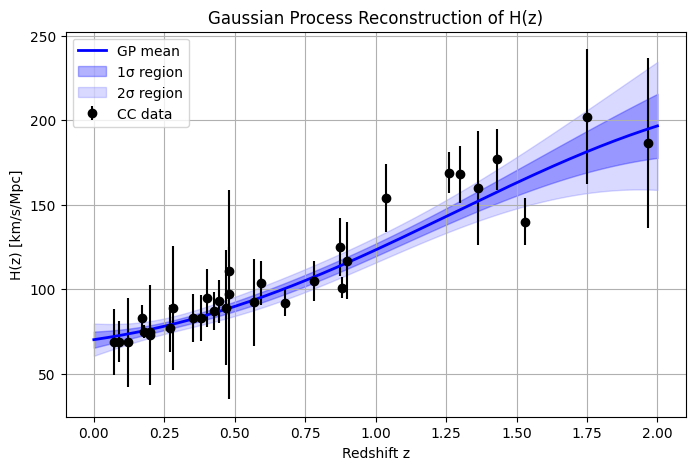

In [7]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Load Cosmic Chronometers data (z, H, error)
data = np.array([
    [0.070, 69.0, 19.6], [0.090, 69.0, 12.0], [0.120, 68.6, 26.2],
    [0.170, 83.0, 8.0],  [0.179, 75.0, 4.0],  [0.199, 75.0, 5.0],
    [0.200, 72.9, 29.6], [0.270, 77.0, 14.0], [0.280, 88.8, 36.6],
    [0.352, 83.0, 14.0], [0.380, 83.0, 13.5], [0.400, 95.0, 17.0],
    [0.425, 87.1, 11.2], [0.445, 92.8, 12.9], [0.470, 89.0, 34.0],
    [0.478, 110.9, 14.4],[0.480, 97.0, 62.0], [0.570, 92.4, 25.7],
    [0.593, 104.0, 13.0], [0.680, 92.0, 8.0],  [0.781, 105.0, 12.0],
    [0.875, 125.0, 17.0], [0.880, 101.0, 6.0], [0.900, 117.0, 23.0],
    [1.037, 154.0, 20.0], [1.260, 169.0, 12.0], [1.300, 168.0, 17.0],
    [1.363, 160.0, 33.6], [1.430, 177.0, 18.0], [1.530, 140.0, 14.0],
    [1.750, 202.0, 40.0], [1.965, 186.5, 50.4]
])

z_obs, h_obs, h_err = data[:, 0].reshape(-1, 1), data[:, 1], data[:, 2]

# Define kernel: sigma_f^2 * RBF(length_scale)
# Bounds are set wide to allow the optimizer to find global best
kernel = C(100.0, (1e-1, 1e10)) * RBF(1.0, (1e-2, 1e2))

# GPR with heteroscedastic noise (alpha=h_err^2)
gp = GaussianProcessRegressor(kernel=kernel, alpha=h_err**2, n_restarts_optimizer=20)
gp.fit(z_obs, h_obs)

# Extract optimized parameters
opt_kernel = gp.kernel_
sigma_f_opt = np.sqrt(opt_kernel.k1.constant_value)
l_opt = opt_kernel.k2.length_scale

# Output results
print(f"Optimized sigma_f: {sigma_f_opt:.4f} (ln_sigmaf: {np.log(sigma_f_opt):.4f})")
print(f"Optimized length_scale: {l_opt:.4f} (ln_l: {np.log(l_opt):.4f})")
print(f"Final Log-Marginal Likelihood: {gp.log_marginal_likelihood_value_:.4f}")
import matplotlib.pyplot as plt
import numpy as np

# 构建绘图用的 z 网格
z_plot = np.linspace(0, 2.0, 200).reshape(-1, 1)

# GP 预测
h_pred, h_std = gp.predict(z_plot, return_std=True)

# 绘制图形
plt.figure(figsize=(8,5))

# 观测点 + 误差条
plt.errorbar(z_obs.flatten(), h_obs, yerr=h_err, fmt='o', color='black', label='CC data')

# GP 预测均值
plt.plot(z_plot, h_pred, color='blue', lw=2, label='GP mean')

# 1σ 区间
plt.fill_between(z_plot.flatten(), h_pred - h_std, h_pred + h_std, color='blue', alpha=0.3, label='1σ region')

# 2σ 区间
plt.fill_between(z_plot.flatten(), h_pred - 2*h_std, h_pred + 2*h_std, color='blue', alpha=0.15, label='2σ region')

# 标签
plt.xlabel('Redshift z')
plt.ylabel('H(z) [km/s/Mpc]')
plt.title('Gaussian Process Reconstruction of H(z)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# 对mB作高斯过程回归 cc和bao
from gauss import GPR
import utils
import pandas as pd
import numpy as np
np.random.seed(42)
sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
mask = (sn_df['IS_CALIBRATOR'] == 0)
z_sn = sn_df.loc[mask, 'zHD'].values
mB_obs = sn_df.loc[mask, 'm_b_corr'].values

idx_sn = sn_df.index[mask].values
mB_cov_full = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")
mB_cov = mB_cov_full[np.ix_(idx_sn, idx_sn)]

z_bao_dv, DV_rd, DV_rd_err = np.loadtxt('data/Combine_DV_rd.dat', unpack=True)
z_bao_dm, DM_rd, DM_rd_err = np.loadtxt('data/Combine_DM_rd.dat', unpack=True)
z_bao = np.concatenate((z_bao_dv, z_bao_dm)) 

z_cc, _, _ = np.loadtxt('data/cc.txt' , unpack=True)

gpr = GPR(l=1.0, sigma_f=100, kernel_name='rbf') 
gpr.fit(np.log(z_sn), mB_obs, mB_cov, optimize_method='minimize') 

mB_baomatch_mean, mB_baomatch_cov = gpr.predict(np.log(z_bao))
np.save('output/mB_baomatch_mean_GPR.npy', mB_baomatch_mean)
np.save('output/mB_baomatch_cov_GPR.npy', mB_baomatch_cov)

mB_ccmatch_mean, mB_ccmatch_cov = gpr.predict(np.log(z_cc))
np.save('output/mB_ccmatch_mean_GPR.npy', mB_ccmatch_mean)
np.save('output/mB_ccmatch_cov_GPR.npy', mB_ccmatch_cov)

In [2]:
# 将误差转化成协方差矩阵
# import numpy as np
# data = np.loadtxt('data/cc.txt')
# errors = data[:, 2]
# cov_matrix = np.diag(errors**2)
# np.savetxt('data/cc_cov.txt', cov_matrix, fmt='%.6e')
# print(cov_matrix.shape)

In [13]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
np.random.seed(42)
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 14
})

Running Chi2 Analysis ...
Processing RBF...
Processing RQ...
Processing DSE...
Processing Matern32...
Processing Matern52...
Processing Matern72...
Processing Matern92...
Kernel   P_k/P_SE   P(SE < k)
RQ            2.232    0.309
DSE           1.839    0.352
Matern32      3.050    0.247
Matern52      2.554    0.281
Matern72      2.331    0.300
Matern92      2.131    0.319


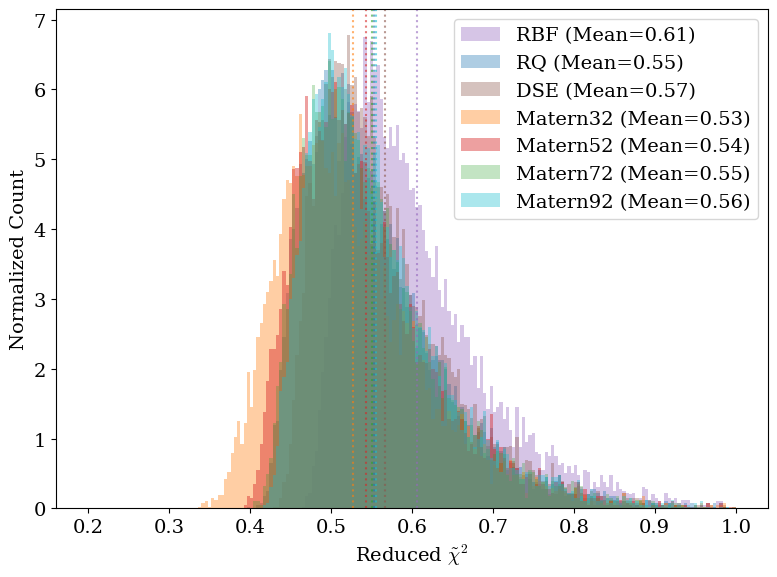

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import utils
import os
np.random.seed(42)
kernels = ['RBF','RQ','DSE','Matern32','Matern52','Matern72','Matern92']
colors = ["#9467bd60","#1f76b45c","#8c564b5c","#ff7e0e60","#d6272770","#2ca02c48","#17becf5c","#bcbd225c"]

data = np.loadtxt('data/cc.txt')
z_obs = data[:,0]
H_obs = data[:,1]
Cov_data = np.loadtxt('data/cc_cov.txt')

# sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
# z_sn, mB_obs, err_sn = sn_df['zHD'].values, sn_df['m_b_corr'].values, sn_df['m_b_corr_err_DIAG'].values
# mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")

# z_cp, mB_cp, mB_cp_std = np.loadtxt("output/mB_cp_summary.txt", unpack= True)
# mB_cp_cov = np.load("output/mB_cp_cov.npy")

results = {}
print("Running Chi2 Analysis ...")
for k in kernels:
    print(f"Processing {k}...")
    results[k] = utils.get_reduced_chi2_samples(z_obs,H_obs,Cov_data,k)

plt.figure(figsize=(8,6))
for k,c in zip(kernels,colors):
    mean_val = np.mean(results[k])
    plt.hist(results[k],bins=200,density=True,histtype='bar',lw=2,color=c,label=f'{k} (Mean={mean_val:.2f})',range=(0.2,1))
    plt.axvline(mean_val,color=c,ls=':',alpha=0.6)

plt.xlabel(r'Reduced $\tilde{\chi}^2$')
plt.ylabel('Normalized Count')
# plt.title(r'Distribution of Reduced $\chi^2$ for different Kernels')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig/kernel_chi2_distribution_hz.pdf')

ref_kernel = 'RBF'
P_ratio = {}

for k in kernels:
    if k == ref_kernel:
        continue
    Ni = np.sum(results[ref_kernel] < results[k])
    Nj = len(results[k]) - Ni
    P_ratio[k] = Nj / Ni

P_win = {}

for k in kernels:
    if k == ref_kernel:
        continue
    Ni = np.sum(results[ref_kernel] < results[k])
    Nj = len(results[k]) - Ni
    P_win[k] = 1.0 / (1.0 + Nj / Ni)
    
print("Kernel   P_k/P_SE   P(SE < k)")
for k in P_ratio:
    print(f"{k:10s} {P_ratio[k]:8.3f} {P_win[k]:8.3f}")



Running Chi2 Analysis ...
Processing RBF...
Processing RQ...
Processing DSE...
Processing Matern32...
Processing Matern52...
Processing Matern72...
Processing Matern92...
Kernel   P_k/P_SE   P(SE < k)
RQ            2.054    0.327
DSE           3.968    0.201
Matern32    525.316    0.002
Matern52     17.215    0.055
Matern72      7.475    0.118
Matern92      4.429    0.184


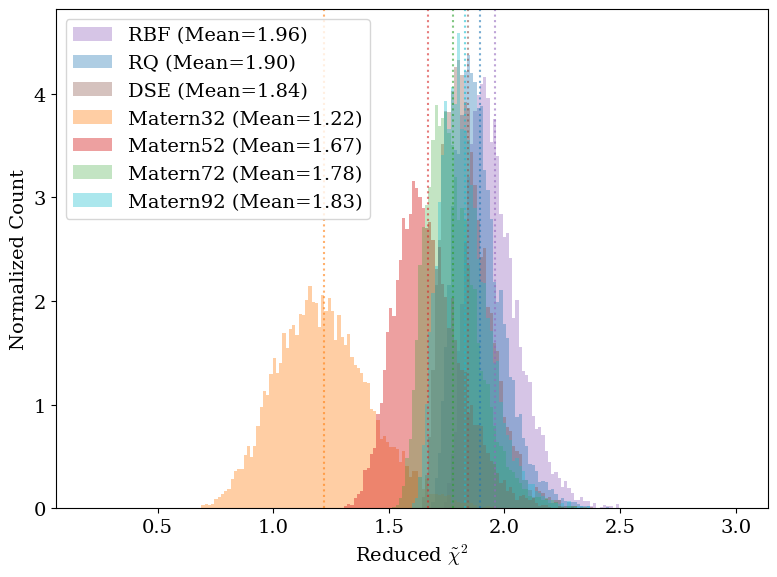

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import utils
import os
np.random.seed(42)
kernels = ['RBF','RQ','DSE','Matern32','Matern52','Matern72','Matern92']
colors = ["#9467bd60","#1f76b45c","#8c564b5c","#ff7e0e60","#d6272770","#2ca02c48","#17becf5c","#bcbd225c"]

# data = np.loadtxt('data/cc.txt')
# z_obs = data[:,0]
# H_obs = data[:,1]
# Cov_data = np.loadtxt('data/cc_cov.txt')

# sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
# z_sn, mB_obs, err_sn = sn_df['zHD'].values, sn_df['m_b_corr'].values, sn_df['m_b_corr_err_DIAG'].values
# mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")

z_cp, mB_cp, mB_cp_std = np.loadtxt("output/mB_cp_summary.txt", unpack= True)
mB_cp_cov = np.load("output/mB_cp_cov.npy")

results = {}
print("Running Chi2 Analysis ...")
for k in kernels:
    print(f"Processing {k}...")
    results[k] = utils.get_reduced_chi2_samples(np.log(z_cp),mB_cp,mB_cp_cov,k)

plt.figure(figsize=(8,6))
for k,c in zip(kernels,colors):
    mean_val = np.mean(results[k])
    plt.hist(results[k],bins=200,density=True,histtype='bar',lw=2,color=c,label=f'{k} (Mean={mean_val:.2f})',range=(0.2,3))
    plt.axvline(mean_val,color=c,ls=':',alpha=0.6)

plt.xlabel(r'Reduced $\tilde{\chi}^2$')
plt.ylabel('Normalized Count')
# plt.title(r'Distribution of Reduced $\chi^2$ for different Kernels')
plt.legend()
plt.tight_layout()
plt.savefig('fig/kernel_chi2_distribution_mB.pdf')

ref_kernel = 'RBF'
P_ratio = {}

for k in kernels:
    if k == ref_kernel:
        continue
    Ni = np.sum(results[ref_kernel] < results[k])
    Nj = len(results[k]) - Ni
    P_ratio[k] = Nj / Ni

P_win = {}

for k in kernels:
    if k == ref_kernel:
        continue
    Ni = np.sum(results[ref_kernel] < results[k])
    Nj = len(results[k]) - Ni
    P_win[k] = 1.0 / (1.0 + Nj / Ni)
    
print("Kernel   P_k/P_SE   P(SE < k)")
for k in P_ratio:
    print(f"{k:10s} {P_ratio[k]:8.3f} {P_win[k]:8.3f}")



Running MCMC...


  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:04<00:00, 451.60it/s]


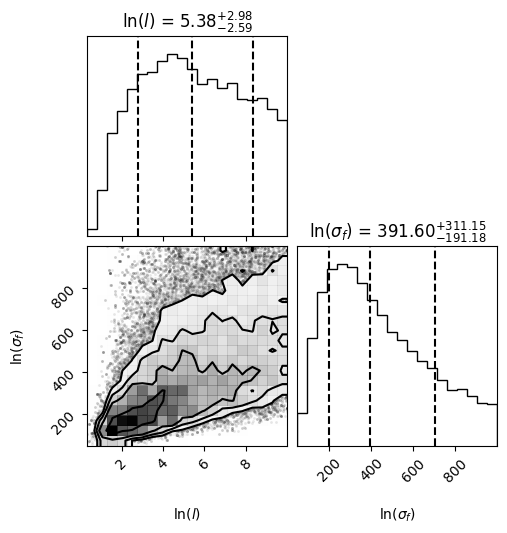

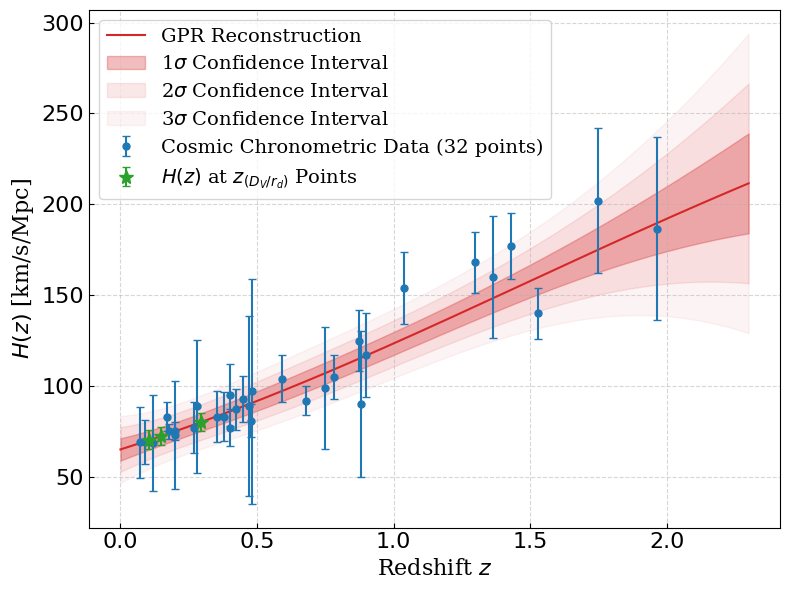

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import utils

# Configuration
KERNEL_NU = 1.5
N_WALKERS = 32
N_STEPS = 2000
BURN_IN = 500

def log_likelihood(theta, x, y, cov, kernel_func, **kwargs):
    l, sigma_f = theta
    K = kernel_func(x, x, [l, sigma_f], **kwargs) 
    A = K + cov
    try:
        L = np.linalg.cholesky(A)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
        return -0.5 * y @ alpha - np.sum(np.log(np.diag(L)))
    except np.linalg.LinAlgError:
        return -np.inf

def log_probability(theta, x, y, cov, kernel_func, **kwargs):
    l, sigma_f = theta
    if not (0 < l < 10) or not (1e-1 < sigma_f < 1e3):
        return -np.inf
    return log_likelihood(theta, x, y, cov, kernel_func, **kwargs)

# Load Data
z_cc, H_data, H_err = np.loadtxt('data/cc.txt', unpack=True)
z_bao, _, _ = np.loadtxt('data/Combine_DV_rd.dat', unpack=True)
H_cov = np.loadtxt('data/cc_cov.txt')

# MCMC Setup
ndim = 2
p0 = np.random.normal([0.5, 150], 0.1, (N_WALKERS, ndim))
sampler = emcee.EnsembleSampler(N_WALKERS, ndim, log_probability, args=(z_cc, H_data, H_cov, utils.gaussian_kernel_vectorization))#, kwargs={"nu": KERNEL_NU})

# Run MCMC
print("Running MCMC...")
sampler.run_mcmc(p0, N_STEPS, progress=True)
theta_samples = sampler.get_chain(discard=BURN_IN, flat=True)


# Plot Corner
fig = corner.corner(theta_samples, labels=[r"$\ln(l)$", r"$\ln(\sigma_f)$"], quantiles=[0.16, 0.5, 0.84], show_titles=True)
fig.savefig(f'fig/corner_nu{KERNEL_NU}.png')
plt.show()


# theta_samples = np.exp(theta_samples)  #important!!!
# Reconstruction
z_plot = np.linspace(0, 2.3, 200)
rec_mean, rec_cov = utils.predict_marginalized(z_cc, H_data, H_cov, z_plot, utils.gaussian_kernel_vectorization, theta_samples)#, nu = KERNEL_NU)
bao_mean, bao_cov = utils.predict_marginalized(z_cc, H_data, H_cov, z_bao, utils.gaussian_kernel_vectorization, theta_samples)#, nu = KERNEL_NU)
rec_std = np.sqrt(np.diag(rec_cov))
bao_std = np.sqrt(np.diag(bao_cov))

# Save Results
np.savetxt(f'output/Hz_BAO_reconstructed_nu{KERNEL_NU}.txt', np.column_stack((z_bao, bao_mean, bao_std)), header="z_BAO H(z) H_std", fmt="%.5f")

# Plot Reconstruction
plt.figure(figsize=(8, 6))
plt.plot(z_plot, rec_mean, color='#d62728', linewidth=1.5, label='GPR Reconstruction')
plt.fill_between(z_plot, rec_mean - rec_std, rec_mean + rec_std, color='#d62728', alpha=0.3, label=r'1$\sigma$ Confidence Interval')
plt.fill_between(z_plot, rec_mean - 2*rec_std, rec_mean + 2*rec_std, color='#d62728', alpha=0.1, label=r'2$\sigma$ Confidence Interval')
plt.fill_between(z_plot, rec_mean - 3*rec_std, rec_mean + 3*rec_std, color='#d62728', alpha=0.05, label=r'3$\sigma$ Confidence Interval')
plt.errorbar(z_cc, H_data, yerr=H_err, fmt='o', color='#1f77b4', ecolor='#1f77b4', capsize=3, markersize=5, label='Cosmic Chronometric Data (32 points)')
plt.errorbar(z_bao, bao_mean, yerr=bao_std, fmt='*', color='#2ca02c', ecolor='#2ca02c', markersize=10, capsize=3, label=r'$H(z)$ at $z_{(D_V/r_d)}$ Points')
plt.xlabel('Redshift $z$', fontsize=16, fontfamily='serif')
plt.ylabel('$H(z)$ [km/s/Mpc]', fontsize=16, fontfamily='serif')
plt.legend(frameon=True, loc='best', prop={'family': 'serif', 'size':14})
plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(axis='both', which='major', labelsize=16, direction='in')
plt.tight_layout()
plt.savefig(f'fig/H_z_reconstruction_nu{KERNEL_NU}.pdf')
plt.show()


In [4]:
theta_samples.mean(axis=0)

array([  9.01327424, 613.87877368])

In [6]:
print("theta_samples shape:", theta_samples.shape)

test = np.log(theta_samples)
print("after log shape:", test.shape)

print("first 5 rows:")
print(test[:5])

theta_samples shape: (48000, 2)
after log shape: (48000, 2)
first 5 rows:
[[0.63146547 4.35910533]
 [1.66759268 4.93677435]
 [2.30953758 5.53268892]
 [3.59008878 6.05114554]
 [3.36220617 7.50617046]]


Removed no burn in


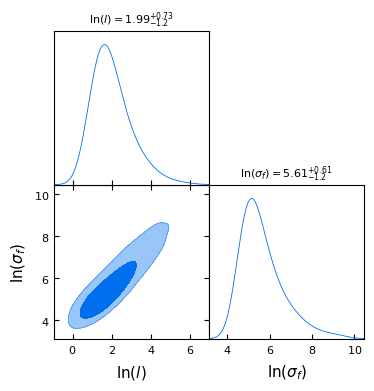

In [7]:
from getdist import MCSamples, plots
%matplotlib inline
names  = ["ln_l", "ln_sigma_f"]
labels = [r"\ln(l)", r"\ln(\sigma_f)"]
gdsamples = MCSamples(
    samples=np.log(theta_samples),
    names=names,
    labels=labels
)
gdsamples.updateSettings({
    'smooth_scale_1D': 0.5,
    'smooth_scale_2D': 0.5
})
g = plots.get_subplot_plotter()
g.triangle_plot(gdsamples, title_limit=1, filled=True)

Integrating 1/H(z) to get DA(z)...


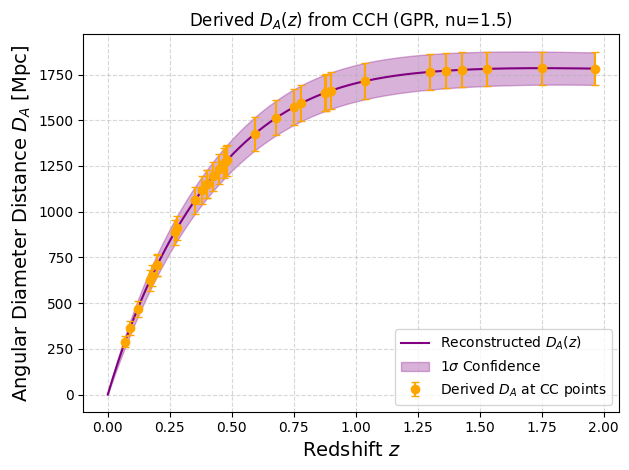

In [ ]:
from scipy.integrate import cumulative_trapezoid

z_integ = np.linspace(0, np.max(z_cc), 500)

mu_h_grid, cov_h_grid = utils.predict_marginalized(
    z_cc, H_data, H_cov, 
    z_integ, 
    utils.matern_kernel, 
    theta_samples, 
    nu=KERNEL_NU
)

N_SAMPLES = 1000
c_light = 299792.458

h_curves = np.random.multivariate_normal(mu_h_grid, cov_h_grid, N_SAMPLES)

da_curves = np.zeros_like(h_curves)

print("Integrating 1/H(z) to get DA(z)...")
for i in range(N_SAMPLES):
    h_path = h_curves[i, :]
    integrand = c_light / h_path
    dc_path = cumulative_trapezoid(integrand, z_integ, initial=0)
    da_curves[i, :] = dc_path / (1 + z_integ)

da_samples_at_cc = np.zeros((N_SAMPLES, len(z_cc)))

for i in range(N_SAMPLES):
    da_samples_at_cc[i, :] = np.interp(z_cc, z_integ, da_curves[i, :])

da_mean = np.mean(da_samples_at_cc, axis=0)
da_cov = np.cov(da_samples_at_cc, rowvar=False)
da_std = np.sqrt(np.diag(da_cov))

np.save('output/da_cc', da_mean)
np.save('output/da_cc_cov', da_cov)

mean_da_curve = np.mean(da_curves, axis=0)
std_da_curve = np.std(da_curves, axis=0)

plt.plot(z_integ, mean_da_curve, color='purple', label=r'Reconstructed $D_A(z)$')
plt.fill_between(z_integ, 
                 mean_da_curve - std_da_curve, 
                 mean_da_curve + std_da_curve, 
                 color='purple', alpha=0.3, label=r'1$\sigma$ Confidence')

plt.errorbar(z_cc, da_mean, yerr=da_std, fmt='o', color='orange', 
             ecolor='orange', capsize=3, label='Derived $D_A$ at CC points')

plt.xlabel('Redshift $z$', fontsize=14)
plt.ylabel('Angular Diameter Distance $D_A$ [Mpc]', fontsize=14)
plt.title(f'Derived $D_A(z)$ from CCH (GPR, nu={KERNEL_NU})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

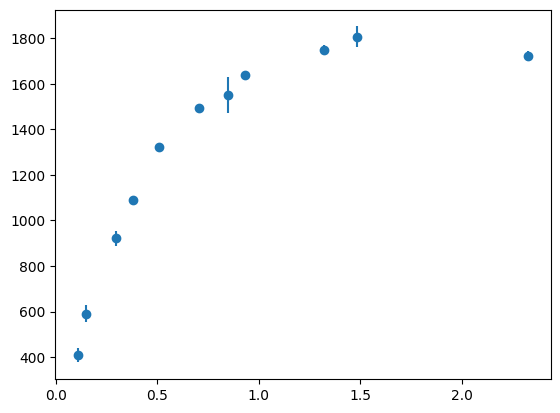

In [9]:
# 从bao数据中得到重构
import numpy as np
import utils
z_bao, bao_val, bao_err= np.loadtxt('data/bao_data.dat', unpack=True)
bao_cov = np.loadtxt('output/bao_cov.txt')
h_val, h_cov_bao = utils.predict_marginalized(
    z_cc, H_data, H_cov, 
    z_bao, 
    utils.matern_kernel, 
    theta_samples, 
    nu=KERNEL_NU
)
# Load BAO data and Hubble GPR results
z, val, _ = np.loadtxt('data/bao_data.dat', unpack=True)
cov_bao = np.loadtxt('output/bao_cov.txt')

c_light, rd_fid, rd_std = 299792.458, 147.09, 0.26
n = len(z)
idx_dv = slice(0, 3) # First 3 points are DV/rd

# 1. Transform DV/rd to DM/rd
dm_val = np.copy(val)
dv, hz = val[idx_dv], h_val[idx_dv]
dm_val[idx_dv] = np.sqrt((dv**3 * hz * rd_fid) / (z[idx_dv] * c_light))

# 2. Construct Jacobian matrices for error propagation
# J_bao: Partial derivatives w.r.t original BAO values
j_b_diag = np.ones(n)
j_b_diag[idx_dv] = 1.5 * dm_val[idx_dv] / val[idx_dv]
J_bao = np.diag(j_b_diag)

# J_h: Partial derivatives w.r.t Hubble parameters
j_h_diag = np.zeros(n)
j_h_diag[idx_dv] = 0.5 * dm_val[idx_dv] / h_val[idx_dv]
J_h = np.diag(j_h_diag)

# J_rd
j_rd = np.zeros(n)
j_rd[idx_dv] = 0.5 * dm_val[idx_dv] / rd_fid
J_rd = j_rd.reshape(-1, 1)   # (n, 1)
C_rd = np.array([[rd_std**2]])  # (1, 1)

# 3. Propagate covariance (handles full non-diagonal matrices)
dm_cov = J_bao @ cov_bao @ J_bao.T + J_h @ h_cov_bao @ J_h.T + J_rd  @ C_rd @ J_rd.T

da_val = dm_val * rd_fid / (1+z_bao)
scales = rd_fid / (1 + z_bao)
S = np.outer(scales, scales)
da_bao_cov = dm_cov * S
plt.errorbar(z_bao, da_val, np.sqrt(np.diag(da_bao_cov)), fmt='o')
plt.show()


In [10]:
np.save('output/da_bao.npy', da_val)
np.save('output/da_bao_cov.npy', da_bao_cov)

Running MCMC...


100%|██████████| 2000/2000 [00:05<00:00, 376.94it/s]


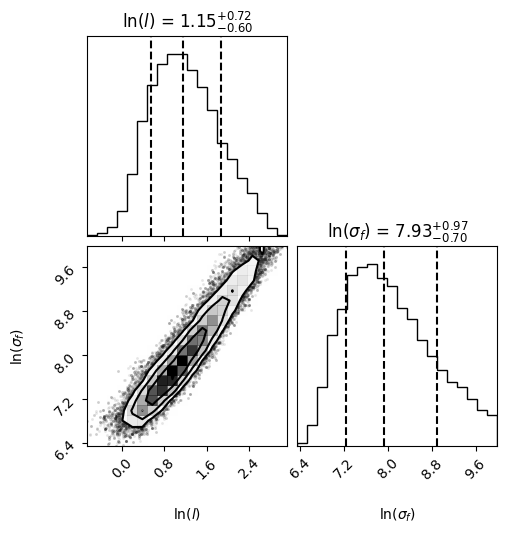

<ErrorbarContainer object of 3 artists>

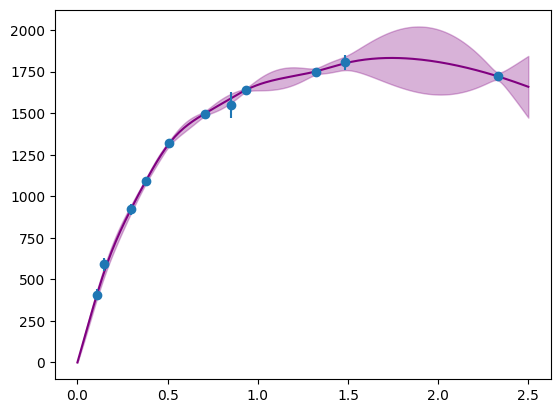

In [11]:
# MCMC Setup
ndim = 2
p0 = np.random.normal([np.log(0.5), np.log(30)], 0.1, (N_WALKERS, ndim))
# sampler = emcee.EnsembleSampler(N_WALKERS, ndim, utils.log_probability, args=(z_bao, da_val, da_bao_cov, utils.matern_kernel), kwargs={"nu": KERNEL_NU})

z_aug = np.concatenate(([0.0], z_bao))
da_aug = np.concatenate(([0.0], da_val))

cov_aug = np.zeros((len(z_aug), len(z_aug)))
cov_aug[1:, 1:] = da_bao_cov
cov_aug[0, 0] = (1e-4)**2
sampler = emcee.EnsembleSampler(
    N_WALKERS, ndim,
    utils.log_probability,
    args=(z_aug, da_aug, cov_aug, utils.matern_kernel),
    kwargs={"nu": KERNEL_NU}
)

# Run MCMC
print("Running MCMC...")
sampler.run_mcmc(p0, N_STEPS, progress=True)
theta_samples_da_bao = sampler.get_chain(discard=BURN_IN, flat=True)


# Plot Corner
fig = corner.corner(theta_samples_da_bao, labels=[r"$\ln(l)$", r"$\ln(\sigma_f)$"], quantiles=[0.16, 0.5, 0.84], show_titles=True)
fig.savefig(f'fig/corner_nu{KERNEL_NU}.png')
plt.show()


theta_samples_da_bao = np.exp(theta_samples_da_bao)  #important!!!
# Reconstruction
z_plot = np.linspace(0, 2.5, 200)
rec_mean, rec_cov = utils.predict_marginalized(z_aug, da_aug, cov_aug, z_plot, utils.matern_kernel, theta_samples_da_bao, nu = KERNEL_NU)
rec_std = np.sqrt(np.diag(rec_cov))


plt.plot(z_plot, rec_mean, color='purple', label=r'Reconstructed $D_A(z)$ from BAO')
plt.fill_between(z_plot, 
                 rec_mean - rec_std, 
                 rec_mean + rec_std, 
                 color='purple', alpha=0.3, label=r'1$\sigma$ Confidence')

# plt.errorbar(z_cc, da_mean, yerr=da_std, fmt='o', color='orange', 
#              ecolor='orange', capsize=3, label='Derived $D_A$ at CC points')
plt.errorbar(z_bao, da_val, np.sqrt(np.diag(da_bao_cov)), fmt='o')

Running MCMC...


100%|██████████| 2000/2000 [00:17<00:00, 111.99it/s]


Removed no burn in


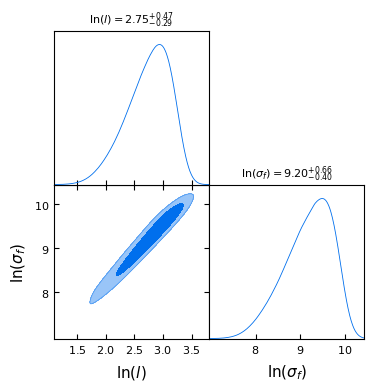

In [12]:
z_da = np.concatenate([z_cc, z_bao])
da   = np.concatenate([da_mean, da_val])

Nc = da_cov.shape[0]
Nb = da_bao_cov.shape[0]

cov_joint = np.zeros((Nc + Nb, Nc + Nb))
cov_joint[:Nc, :Nc] = da_cov
cov_joint[Nc:, Nc:] = da_bao_cov

sort_idx = np.argsort(z_da)
z_da_sorted = z_da[sort_idx]
da_sorted   = da[sort_idx]
cov_sorted  = cov_joint[np.ix_(sort_idx, sort_idx)]

sigma0 = 1e-4
z_final  = np.concatenate([[0.0], z_da_sorted])
da_final = np.concatenate([[0.0], da_sorted])

cov_final = np.zeros((len(z_final), len(z_final)))
cov_final[1:, 1:] = cov_sorted
cov_final[0, 0]   = sigma0**2


sampler = emcee.EnsembleSampler(
    N_WALKERS, ndim,
    utils.log_probability,
    args=(z_final, da_final, cov_final, utils.matern_kernel),
    kwargs={"nu": KERNEL_NU}
)

print("Running MCMC...")
sampler.run_mcmc(p0, N_STEPS, progress=True)
theta_samples_union = sampler.get_chain(discard=BURN_IN, flat=True)

from getdist import MCSamples, plots
%matplotlib inline
names  = ["ln_l", "ln_sigma_f"]
labels = [r"\ln(l)", r"\ln(\sigma_f)"]
gdsamples = MCSamples(
    samples=theta_samples_union,
    names=names,
    labels=labels
)
gdsamples.updateSettings({
    'smooth_scale_1D': 0.5,
    'smooth_scale_2D': 0.5
})
g = plots.get_subplot_plotter()
g.triangle_plot(gdsamples, title_limit=1, filled=True)


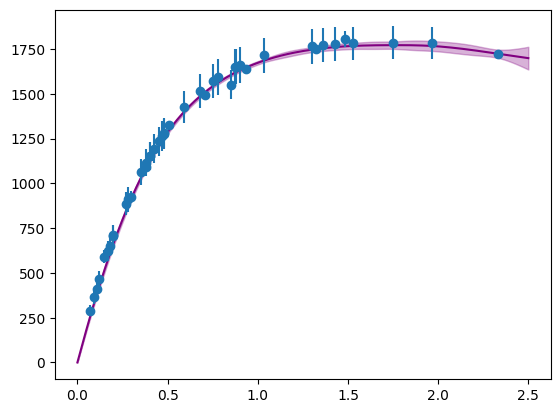

In [13]:
z_plot = np.linspace(0, 2.5, 200)
rec_mean, rec_cov = utils.predict_marginalized(z_final, da_final, cov_final, z_plot, utils.matern_kernel, np.exp(theta_samples_union), nu = KERNEL_NU)
rec_std = np.sqrt(np.diag(rec_cov))


plt.plot(z_plot, rec_mean, color='purple', label=r'Reconstructed $D_A(z)$ from BAO')
plt.fill_between(z_plot, 
                 rec_mean - rec_std, 
                 rec_mean + rec_std, 
                 color='purple', alpha=0.3, label=r'1$\sigma$ Confidence')

plt.errorbar(z_da_sorted, da_sorted, np.sqrt(np.diag(cov_sorted)), fmt='o')
plt.show()
np.savetxt("output/da_summary.txt", np.c_[z_da_sorted, da_sorted, np.sqrt(np.diag(cov_sorted))], header="z_da_sorted  da_sorted  da_sorted_std")
np.save("output/da_theta_samples.npy", theta_samples_union)
np.save("output/da_cov.npy", cov_sorted)

In [14]:
import numpy as np
z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
z_bao = z_bao.astype(float)
mask = (bao_type == 'DH_over_rs')
z_DH_rs  = z_bao[mask]
z_exclude_DV = z_DH_rs
Hz_exclude_DV, Hz_exclude_DV_cov = utils.predict_marginalized(z_cc, H_data, H_cov, z_exclude_DV, utils.matern_kernel, theta_samples, nu = KERNEL_NU)
np.save('output/Hz_exclude_DV.npy', Hz_exclude_DV)
np.save('output/Hz_exclude_DV_cov.npy', Hz_exclude_DV_cov)

In [ ]:
# import numpy as np
# data = np.loadtxt('\')
# errors = data[:, 2]
# cov_matrix = np.diag(errors**2)
# np.savetxt('output/cc_cov_diag.txt', cov_matrix, fmt='%.6e')
# print(cov_matrix.shape)